# Exercise 1 — Logistic Regression

## Part A: Understanding Logistic Regression

Imagine we want to predict whether a student will pass an exam.

For each student, we know:

* the number of study hours
* whether the student passed or failed

Our goal is to predict: `pass (1) or fail (0)`

Unlike linear regression, logistic regression predicts a probability between 0 and 1.

### Logistic Regression Model

The model is:

`z = weight × x + bias`

Then we apply the sigmoid function:

`p = 1 / (1 + e^(-z))`

Where:

* x = input feature (study hours)
* weight = importance of the feature
* bias = shifts the curve
* p = probability of passing

### Decision Rule

After computing the probability:

`if p > 0.5 → predict PASS

else → predict FAIL`

Your Task

Change the values of: `weight` and `bias` as in previous exercises.

until the sigmoid curve separates the two classes as well as possible.

Try to understand:

* what the weight changes
* what the bias changes
* where the decision boundary appears

### Sample Student Data

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# x = study hours
x = np.array([0,1,2,3,4,5,6,7,8,9])

# y = fail(0) or pass(1)
y = np.array([0,0,0,0,0,1,1,1,1,1])

In [43]:
weight = 1.85
bias = -10

### Logistic Regression Predictions

In [44]:
# Linear part
z = weight * x + bias

# Sigmoid
p = 1 / (1 + np.exp(-z))

# Predicted classes
y_pred = (p > 0.5).astype(int)

### Plot the model

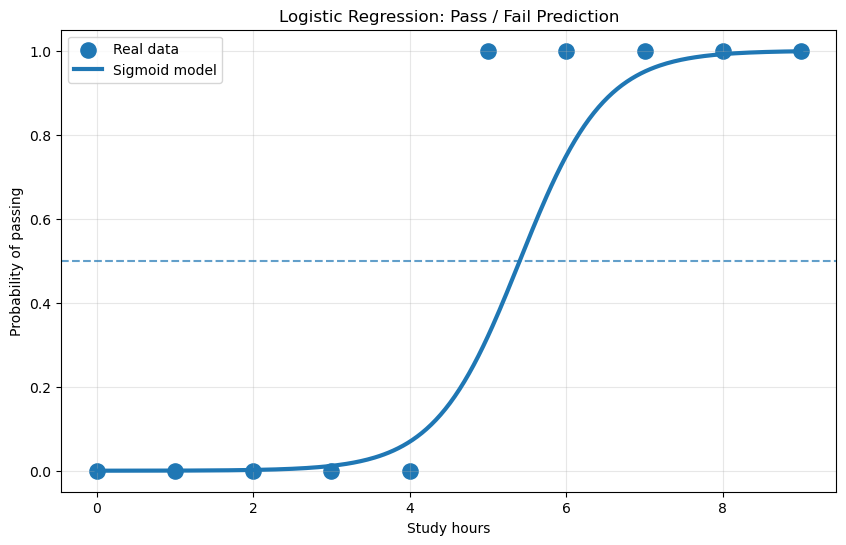

In [45]:
plt.figure(figsize=(10,6))

# Real data
plt.scatter(x, y, s=120, label="Real data")

# Smooth sigmoid curve
x_curve = np.linspace(0, 9, 300)
z_curve = weight * x_curve + bias
p_curve = 1 / (1 + np.exp(-z_curve))

plt.plot(x_curve, p_curve, linewidth=3, label="Sigmoid model")

# Decision threshold
plt.axhline(0.5, linestyle="--", alpha=0.7)

plt.xlabel("Study hours")
plt.ylabel("Probability of passing")
plt.title("Logistic Regression: Pass / Fail Prediction")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

Questions

1. What does the weight control? Weight: controls the steepness of the sigmoid curve
2. What does the bias control? Bias: controls the horizontal shift of the curve
3. What happens when the sigmoid becomes steeper? When the sigmoid becomes steeper, the model becomes more sensitive to small changes in the input x
4. Where is the decision boundary? The decision boundary is located where the predicted probability p = 0.5. In my diagram this occurs at approximately 5.5 study hours.
5. Which students are difficult to classify? Students with study hours near the decision boundary (around 5 hours) are the most difficult to classify because their predicted probability is close to 0.5, indicating high uncertainty.
6. Why is logistic regression better than linear regression here? Logistic regression is better because it constrains predictions to 0 and 1, which represents probability.

## Part B — Use a Real Dataset

Now repeat the same process using a real dataset.

Choose:

- one numerical column as `x`
- one binary column as `y`

Below are beginner-friendly datasets you can use.

| Dataset | Link | Example `x` | Example `y` | Task |
|---|---|---|---|---|
| Titanic | [Open dataset](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv) | `Age`, `Fare` | `Survived` | Predict survival |
| Breast Cancer Wisconsin | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) | `mean radius`, `mean texture` | `target` | Benign vs malignant |
| Heart Disease | [Open dataset](https://archive.ics.uci.edu/dataset/45/heart+disease) | `cholesterol`, `age` | `disease` | Predict heart disease |
| Palmer Penguins | [Open dataset](https://github.com/allisonhorst/palmerpenguins) | `bill_length_mm`, `body_mass_g` | species converted to binary | Classify penguin species |
| Student Performance | [Open dataset](https://archive.ics.uci.edu/dataset/320/student+performance) | `studytime`, `absences` | pass/fail from final grade | Predict pass/fail |
| SMS Spam | [Open dataset](https://archive.ics.uci.edu/dataset/228/sms+spam+collection) | message length, number of keywords | spam / ham | Spam detection |

### Suggested choice 

Use the **Titanic dataset** first:

In [74]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Your Real-Data Task

1. Load the dataset.
2. Display the first rows with df.head().
3. Choose one feature x.
4. Choose one binary target y.
5. Plot the data.
6. Try different values of weight and bias.
7. Observe how the sigmoid changes.
8. Compare your intuition with Python’s logistic regression model.

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["label"] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
x = df[['mean perimeter']].head(50).to_numpy()
y = df['label'].head(50).to_numpy()

In [3]:
weight = -1
bias = 80

In [4]:
# Linear part
z = weight * x + bias

# Sigmoid
p = 1 / (1 + np.exp(-z))

# Predicted classes
y_pred = (p > 0.5).astype(int)

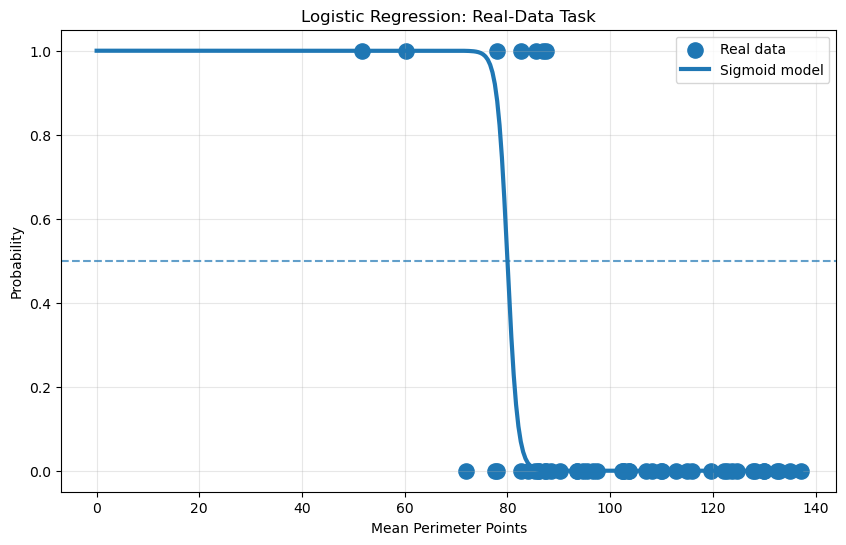

In [5]:
plt.figure(figsize=(10,6))

# Real data
plt.scatter(x, y, s=120, label="Real data")

# Smooth sigmoid curve
x_curve = np.linspace(0, x.max(), 300)
z_curve = weight * x_curve + bias
p_curve = 1 / (1 + np.exp(-z_curve))

plt.plot(x_curve, p_curve, linewidth=3, label="Sigmoid model")

# Decision threshold
plt.axhline(0.5, linestyle="--", alpha=0.7)

plt.xlabel("Mean Perimeter Points")
plt.ylabel("Probability")
plt.title("Logistic Regression: Real-Data Task")

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [7]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y[:len(y_pred)], y_pred)

print(cm)

[[40  3]
 [ 4  3]]


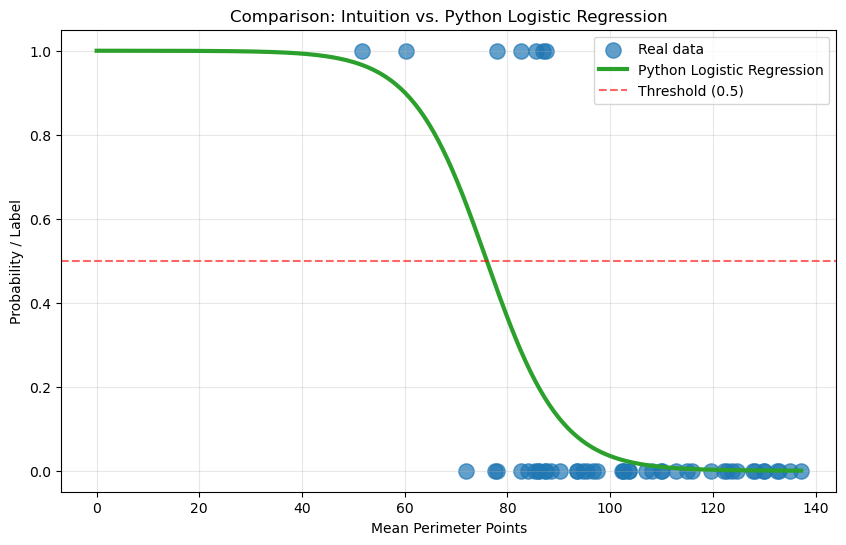

In [91]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

X_train = x.reshape(-1, 1) 
y_train = y 

clf = LogisticRegression()
clf.fit(X_train, y_train)

x_curve = np.linspace(0, x.max(), 300).reshape(-1, 1)
p_curve = clf.predict_proba(x_curve)[:, 1]

plt.figure(figsize=(10, 6))

plt.scatter(x, y, s=120, label="Real data", alpha=0.7)

# Python's Model Curve
plt.plot(x_curve, p_curve, linewidth=3, label="Python Logistic Regression", color="tab:green")

# Decision Threshold
plt.axhline(0.5, color="red", linestyle="--", alpha=0.6, label="Threshold (0.5)")

# Formatting
plt.xlabel("Mean Perimeter Points")
plt.ylabel("Probability / Label")
plt.title("Comparison: Intuition vs. Python Logistic Regression")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()
